# 2026 COMP90042 Project


# Readme

If there is something to be noted for the marker, please mention here.

If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [1]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    DRIVE_DIR = Path("/content/drive/MyDrive/COMP90042/data")
except ImportError:
    IN_COLAB = False
    # Use the local data folder when the notebook is not running on Colab.
    DRIVE_DIR = Path("data")

print("Running in Colab:", IN_COLAB)
print("Data directory  :", DRIVE_DIR.resolve())


Running in Colab: False
Data directory  : C:\Code\COMP90042_2026\data


In [2]:
import json
from collections import Counter

required_files = [
    "train-claims.json",
    "dev-claims.json",
    "test-claims-unlabelled.json",
    "evidence.json",
    "dev-claims-baseline.json",
]

for file_name in required_files:

    file_path = DRIVE_DIR / file_name

    print(file_name, "exists:", file_path.exists())

def load_json(path):

    with open(path, "r", encoding="utf-8") as f:

        return json.load(f)

train_claims = load_json(DRIVE_DIR / "train-claims.json")
dev_claims = load_json(DRIVE_DIR / "dev-claims.json")
test_claims = load_json(DRIVE_DIR / "test-claims-unlabelled.json")
evidence = load_json(DRIVE_DIR / "evidence.json")
dev_baseline = load_json(DRIVE_DIR / "dev-claims-baseline.json")

print("\n===Dataset Overview===\n")
print("Train claims:", len(train_claims))
print("Dev claims:", len(dev_claims))
print("Test claims:", len(test_claims))
print("Evidence:", len(evidence))
print("Dev baseline:", len(dev_baseline))


train-claims.json exists: True
dev-claims.json exists: True
test-claims-unlabelled.json exists: True
evidence.json exists: True
dev-claims-baseline.json exists: True

===Dataset Overview===

Train claims: 1228
Dev claims: 154
Test claims: 153
Evidence: 1208827
Dev baseline: 154


In [3]:
LABELS = ["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]

label_id = {label: idx for idx, label in enumerate(LABELS)}
id_label = {idx: label for label, idx in label_id.items()}

print("===Label mapping===\n")

for label in LABELS:

    print(f"{label:16s} -> {label_id[label]}")

===Label mapping===

SUPPORTS         -> 0
REFUTES          -> 1
NOT_ENOUGH_INFO  -> 2
DISPUTED         -> 3


In [4]:
def validate_labelled_claims(claims, split_name):

    required_fields = {"claim_text", "claim_label", "evidences"}
    problems = []

    for claim_id, item in claims.items():

        missing_fields = required_fields.difference(item.keys())

        if missing_fields:

            problems.append((claim_id, sorted(missing_fields)))

        elif item["claim_label"] not in label_id:

            problems.append((claim_id, ["invalid claim_label"]))

        elif not isinstance(item["evidences"], list):

            problems.append((claim_id, ["evidences is not a list"]))

        elif len(item["evidences"]) == 0:

            problems.append((claim_id, ["empty evidences"]))

    if problems:

        print(f"{split_name} has format problems:")
        print(problems[:5])

    else:

        print(f"{split_name}: format OK ({len(claims):,} claims)")


def validate_unlabelled_claims(claims, split_name):

    problems = []

    for claim_id, item in claims.items():

        if "claim_text" not in item:

            problems.append((claim_id, ["missing claim_text"]))

    if problems:

        print(f"{split_name} has format problems:")
        print(problems[:5])

    else:

        print(f"{split_name}: format OK ({len(claims):,} claims)")

print("===Dataset Inspection===\n")
validate_labelled_claims(train_claims, "Train")
validate_labelled_claims(dev_claims, "Dev")
validate_unlabelled_claims(test_claims, "Test")



===Dataset Inspection===

Train: format OK (1,228 claims)
Dev: format OK (154 claims)
Test: format OK (153 claims)


=== Label Distribution ===



,Label,Train,Dev,Train %,Dev %
0,SUPPORTS,519,68,42.263844,44.155844
2,NOT_ENOUGH_INFO,386,41,31.433225,26.623377
1,REFUTES,199,27,16.205212,17.532468
3,DISPUTED,124,18,10.097720,11.688312


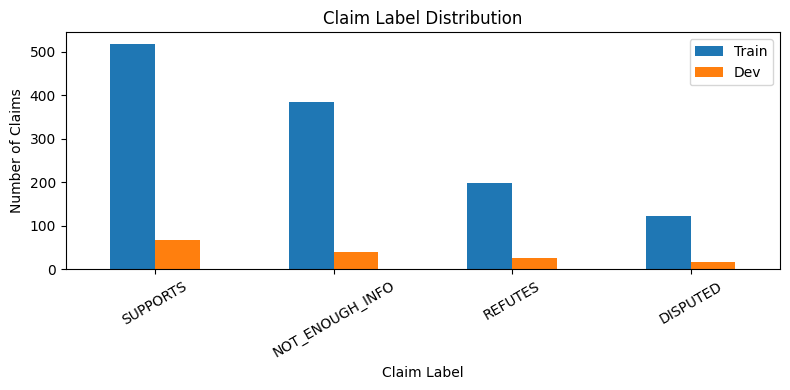

=== Gold Evidence Count Summary ===


,Split,Min,Max,Mean,Median
0,Train,1,5,3.356678,3.0
1,Dev,1,5,3.188312,3.0


=== Gold Evidence Count Distribution ===


,Train,Dev
Number of Gold Evidences,,
1,210,31
2,223,29
3,191,26
4,127,16
5,477,52


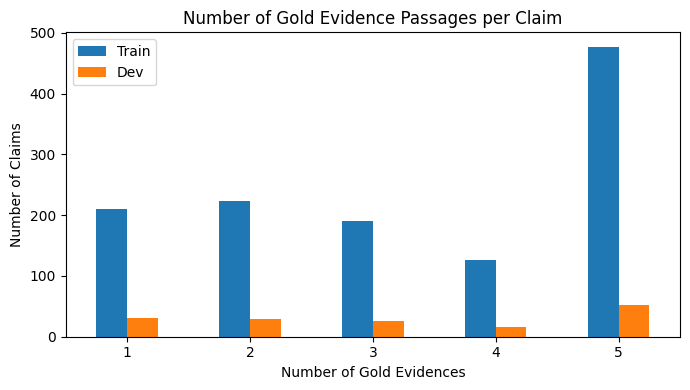

=== Claim Length Statistics ===


,Split,Min,Max,Mean,Median
0,Train,4,67,20.097720,19.0
1,Dev,4,65,21.084416,18.0


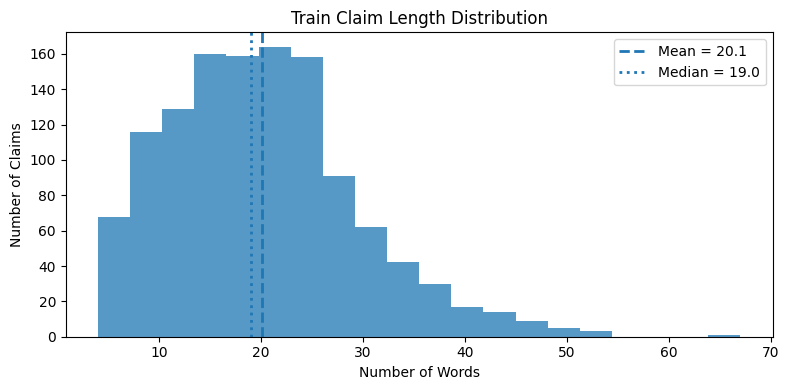

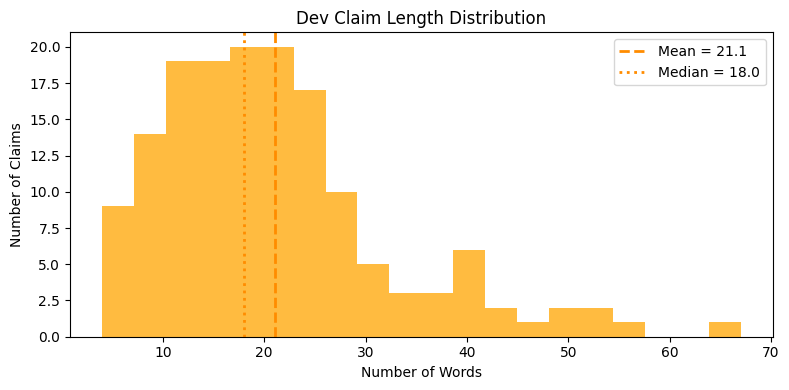

In [5]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====Label Distribution====

train_counts = Counter(item["claim_label"] for item in train_claims.values())
dev_counts = Counter(item["claim_label"] for item in dev_claims.values())

label_table = pd.DataFrame({
    "Label": LABELS,
    "Train": [train_counts[label] for label in LABELS],
    "Dev": [dev_counts[label] for label in LABELS],
})

label_table["Train %"] = label_table["Train"] / len(train_claims) * 100
label_table["Dev %"] = label_table["Dev"] / len(dev_claims) * 100
label_table = label_table.sort_values("Train", ascending=False)

print("=== Label Distribution ===\n")
display(label_table)

label_table.set_index("Label")[["Train", "Dev"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Claim Label Distribution")
plt.xlabel("Claim Label")
plt.ylabel("Number of Claims")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Check how many gold evidence passages each claim has.

train_evidence_counts = [
    len(item["evidences"]) for item in train_claims.values()
]

dev_evidence_counts = [
    len(item["evidences"]) for item in dev_claims.values()
]

evidence_count_summary = pd.DataFrame({
    "Split": ["Train", "Dev"],
    "Min": [min(train_evidence_counts), min(dev_evidence_counts)],
    "Max": [max(train_evidence_counts), max(dev_evidence_counts)],
    "Mean": [np.mean(train_evidence_counts), np.mean(dev_evidence_counts)],
    "Median": [np.median(train_evidence_counts), np.median(dev_evidence_counts)],
})

print("=== Gold Evidence Count Summary ===")
display(evidence_count_summary)

evidence_count_table = pd.DataFrame({
    "Train": pd.Series(train_evidence_counts).value_counts().sort_index(),
    "Dev": pd.Series(dev_evidence_counts).value_counts().sort_index(),
}).fillna(0).astype(int)

evidence_count_table.index.name = "Number of Gold Evidences"

print("=== Gold Evidence Count Distribution ===")
display(evidence_count_table)

evidence_count_table.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Number of Gold Evidence Passages per Claim")
plt.xlabel("Number of Gold Evidences")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Check claim length patterns.
train_claim_lengths = [
    len(item["claim_text"].split()) for item in train_claims.values()
]

dev_claim_lengths = [
    len(item["claim_text"].split()) for item in dev_claims.values()
]

claim_length_table = pd.DataFrame({
    "Split": ["Train", "Dev"],
    "Min": [min(train_claim_lengths), min(dev_claim_lengths)],
    "Max": [max(train_claim_lengths), max(dev_claim_lengths)],
    "Mean": [np.mean(train_claim_lengths), np.mean(dev_claim_lengths)],
    "Median": [np.median(train_claim_lengths), np.median(dev_claim_lengths)],
})

print("=== Claim Length Statistics ===")
display(claim_length_table)

# Use the same bins so the train and dev plots are easy to compare.
x_min = min(min(train_claim_lengths), min(dev_claim_lengths))
x_max = max(max(train_claim_lengths), max(dev_claim_lengths))
bins = np.linspace(x_min, x_max, 21)

train_mean = np.mean(train_claim_lengths)
train_median = np.median(train_claim_lengths)

plt.figure(figsize=(8, 4))
plt.hist(train_claim_lengths, bins=bins, alpha=0.75)

plt.axvline(
    train_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {train_mean:.1f}"
)

plt.axvline(
    train_median,
    linestyle=":",
    linewidth=2,
    label=f"Median = {train_median:.1f}"
)

plt.title("Train Claim Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Claims")
plt.legend()
plt.tight_layout()
plt.show()

dev_mean = np.mean(dev_claim_lengths)
dev_median = np.median(dev_claim_lengths)

plt.figure(figsize=(8, 4))
plt.hist(dev_claim_lengths, bins=bins, alpha=0.75, color="orange")

plt.axvline(
    dev_mean,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {dev_mean:.1f}"
)

plt.axvline(
    dev_median,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label=f"Median = {dev_median:.1f}"
)

plt.title("Dev Claim Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Claims")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import re

def clean_text(text):
    """
    Light text cleaning.
    Only normalise whitespace; keep numbers, units, punctuation, and symbols.
    """
    text = str(text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

evidence_ids = list(evidence.keys())
evidence_texts = [clean_text(evidence[eid]) for eid in evidence_ids]

evidence_id_to_index = {
    eid: idx for idx, eid in enumerate(evidence_ids)
}

evidence_lengths = [
    len(text.split()) for text in evidence_texts
]

empty_evidence_count = sum(
    1 for text in evidence_texts if text == ""
)

print("=== Evidence Corpus Overview ===\n")
print(f"Evidence passages : {len(evidence_texts):,}")
print(f"Empty passages    : {empty_evidence_count:,}")
print(f"Mean length       : {np.mean(evidence_lengths):.1f} words")
print(f"Median length     : {np.median(evidence_lengths):.1f} words")
print(f"Max length        : {max(evidence_lengths)} words")

=== Evidence Corpus Overview ===

Evidence passages : 1,208,827
Empty passages    : 0
Mean length       : 19.7 words
Median length     : 18.0 words
Max length        : 479 words


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [7]:
import importlib.util
import subprocess
import sys
import os
import random
import warnings
import tempfile
from pathlib import Path

required_packages = {
    "torch": "torch",
    "transformers": "transformers",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
    "rank_bm25": "rank_bm25",
    "sentence_transformers": "sentence-transformers",
}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
else:
    print("All modelling packages are already installed.")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util as st_util
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Use the same evaluation script path in Colab and local runs.
if IN_COLAB:
    EVAL_PATH = Path("/content/drive/MyDrive/COMP90042/eval.py")
else:
    EVAL_PATH = Path("eval.py")

print("Evaluation script exists:", EVAL_PATH.exists())


All modelling packages are already installed.


c:\Users\bianc\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Evaluation script exists: True


In [8]:
# Final retrieval settings.
TOP_K = 5
TFIDF_MAX_FEATURES = 50_000
HYBRID_CANDIDATE_POOL = 300
RERANK_MODEL = "multi-qa-MiniLM-L6-cos-v1"
TOP_K_RUNTIME = TOP_K
SEMANTIC_RERANK_WEIGHT = 0.8
SPARSE_RERANK_WEIGHT = 1.0 - SEMANTIC_RERANK_WEIGHT
MAIN_RETRIEVAL_METHOD = "TF-IDF + BM25 -> blended semantic rerank (pool=300, semantic=0.8)"

# Final classifier settings.
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 20
PATIENCE = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01
USE_CLASS_WEIGHTS = False
CLASS_WEIGHT_POWER = 0.5
TRAIN_EVIDENCE_MODE = "retrieved"
CHECKPOINT_SELECTION_METRIC = "accuracy"

# Runtime switches.
FORCE_RETRAIN_BERT = True
TRAIN_FINAL_ON_TRAIN_DEV = False

# Save outputs beside the notebook locally, and in Drive on Colab.
if IN_COLAB:
    PROJECT_ROOT = Path("/content/drive/MyDrive/COMP90042")
else:
    PROJECT_ROOT = Path(".")

TRAIN_CKPT_PATH = str(PROJECT_ROOT / "best_bert_classifier.pt")
FINAL_CKPT_PATH = str(PROJECT_ROOT / "final_bert_classifier.pt")
DEV_PRED_PATH = str(PROJECT_ROOT / "dev-claims-predictions.json")
BASELINE_PRED_PATH = str(PROJECT_ROOT / "dev-claims-baseline-predictions.json")
TEST_PRED_PATH = str(PROJECT_ROOT / "test-claims-predictions.json")

print("=== Hyperparameters ===")
print(f"MAIN_RETRIEVAL_METHOD    : {MAIN_RETRIEVAL_METHOD}")
print(f"TOP_K                    : {TOP_K}")
print(f"TFIDF_MAX_FEATURES       : {TFIDF_MAX_FEATURES}")
print(f"HYBRID_CANDIDATE_POOL    : {HYBRID_CANDIDATE_POOL}")
print(f"RERANK_MODEL             : {RERANK_MODEL}")
print(f"SEMANTIC_RERANK_WEIGHT   : {SEMANTIC_RERANK_WEIGHT}")
print(f"SPARSE_RERANK_WEIGHT     : {SPARSE_RERANK_WEIGHT}")
print(f"MODEL_NAME               : {MODEL_NAME}")
print(f"MAX_LENGTH               : {MAX_LENGTH}")
print(f"BATCH_SIZE               : {BATCH_SIZE}")
print(f"NUM_EPOCHS               : {NUM_EPOCHS}")
print(f"PATIENCE                 : {PATIENCE}")
print(f"TRAIN_EVIDENCE_MODE      : {TRAIN_EVIDENCE_MODE}")
print(f"USE_CLASS_WEIGHTS        : {USE_CLASS_WEIGHTS}")
print(f"CLASS_WEIGHT_POWER       : {CLASS_WEIGHT_POWER}")
print(f"CHECKPOINT_METRIC        : {CHECKPOINT_SELECTION_METRIC}")
print(f"FORCE_RETRAIN_BERT       : {FORCE_RETRAIN_BERT}")
print(f"TRAIN_FINAL_ON_TRAIN_DEV : {TRAIN_FINAL_ON_TRAIN_DEV}")



=== Hyperparameters ===
MAIN_RETRIEVAL_METHOD    : TF-IDF + BM25 -> blended semantic rerank (pool=300, semantic=0.8)
TOP_K                    : 5
TFIDF_MAX_FEATURES       : 50000
HYBRID_CANDIDATE_POOL    : 300
RERANK_MODEL             : multi-qa-MiniLM-L6-cos-v1
SEMANTIC_RERANK_WEIGHT   : 0.8
SPARSE_RERANK_WEIGHT     : 0.19999999999999996
MODEL_NAME               : distilbert-base-uncased
MAX_LENGTH               : 256
BATCH_SIZE               : 16
NUM_EPOCHS               : 20
PATIENCE                 : 3
TRAIN_EVIDENCE_MODE      : retrieved
USE_CLASS_WEIGHTS        : False
CLASS_WEIGHT_POWER       : 0.5
CHECKPOINT_METRIC        : accuracy
FORCE_RETRAIN_BERT       : True
TRAIN_FINAL_ON_TRAIN_DEV : False


In [9]:
class EvidenceRetriever:
    """Hybrid evidence retriever used in the final system."""

    def __init__(self, evidence_ids, evidence_texts, clean_fn=clean_text
                 ,top_k=TOP_K, candidate_pool=HYBRID_CANDIDATE_POOL,print_stats=True):
        self.evidence_ids = list(evidence_ids)
        self.evidence_texts = list(evidence_texts)
        self.clean_fn = clean_fn
        self.print_stats = print_stats
        self.top_k = top_k
        self.candidate_pool = candidate_pool
        self.vectorizer = None
        self.tfidf_matrix = None
        self.bm25 = None
        self.reranker = None

    @staticmethod
    def tokenize(text):
        return re.sub(r"[^\w\s]", "", str(text).lower()).split()

    @staticmethod
    def _safe_top_indices(scores, k):
        scores = np.asarray(scores)
        if len(scores) == 0:
            return np.array([], dtype=int)
        k = min(k, len(scores))
        if len(scores) <= k:
            return np.argsort(scores)[::-1]
        part = np.argpartition(scores, -k)[-k:]
        return part[np.argsort(scores[part])[::-1]]

    @staticmethod
    def _top_from_sparse_row(row, k):
        data = row.data
        indices = row.indices
        if len(data) == 0:
            return np.array([], dtype=int), np.array([], dtype=np.float32)
        k = min(k, len(data))
        if len(data) > k:
            part = np.argpartition(data, -k)[-k:]
            part = part[np.argsort(data[part])[::-1]]
        else:
            part = np.argsort(data)[::-1]
        return indices[part], data[part]

    def fit(self):
        if self.print_stats:
            print("Building TF-IDF index for final retriever...")
        self.vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, stop_words="english")
        self.tfidf_matrix = self.vectorizer.fit_transform(self.evidence_texts)
        if self.print_stats:
            print(f"  TF-IDF matrix: {self.tfidf_matrix.shape}")

        if self.print_stats:
            print("Building BM25 index for final retriever...")
        self.bm25 = BM25Okapi([self.tokenize(text) for text in self.evidence_texts])
        if self.print_stats:
            print("  BM25 ready.")

        if self.print_stats:
            print(f"Loading semantic reranker: {RERANK_MODEL} ...")
        self.reranker = SentenceTransformer(RERANK_MODEL)
        if self.print_stats:
            print("  Reranker ready.")
        return self

    def set_supervised_prior(self, labelled_claims):
        # Keep this method so older notebook calls still run.
        if self.print_stats:
            print("Supervised prior is not used by the final hybrid-semantic retriever.")
        return self

    def retrieve_tfidf(self, claim_text, top_k=TOP_K):
        q = self.vectorizer.transform([self.clean_fn(claim_text)])
        row = (q @ self.tfidf_matrix.T).getrow(0)
        top_idx, _ = self._top_from_sparse_row(row, top_k)
        if len(top_idx) == 0:
            return [self.evidence_ids[0]]
        return [self.evidence_ids[int(i)] for i in top_idx]

    def retrieve_bm25(self, claim_text, top_k=TOP_K):
        scores = self.bm25.get_scores(self.tokenize(claim_text))
        top_idx = self._safe_top_indices(scores, top_k)
        return [self.evidence_ids[int(i)] for i in top_idx]

    def retrieve_tfidf_bm25(self, claim_text, top_k=TOP_K, pool=100):
        q = self.vectorizer.transform([self.clean_fn(claim_text)])
        row = (q @ self.tfidf_matrix.T).getrow(0)
        pool_idx, _ = self._top_from_sparse_row(row, pool)
        if len(pool_idx) == 0:
            return [self.evidence_ids[0]]

        bm25_scores = np.asarray(self.bm25.get_scores(self.tokenize(claim_text)))[pool_idx]
        top_in_pool = self._safe_top_indices(bm25_scores, top_k)
        return [self.evidence_ids[int(pool_idx[i])] for i in top_in_pool]

    def retrieve_hybrid_semantic(self, claim_text, top_k=TOP_K, pool=HYBRID_CANDIDATE_POOL):
        clean_claim = self.clean_fn(claim_text)

        # Score the full evidence corpus before semantic reranking.
        q = self.vectorizer.transform([clean_claim])
        tfidf_row = (q @ self.tfidf_matrix.T).getrow(0)
        tfidf_scores = np.zeros(len(self.evidence_ids), dtype=np.float32)
        if len(tfidf_row.data) > 0:
            tfidf_scores[tfidf_row.indices] = tfidf_row.data.astype(np.float32)

        bm25_scores = np.asarray(self.bm25.get_scores(self.tokenize(clean_claim)), dtype=np.float32)
        tfidf_norm = tfidf_scores / (tfidf_scores.max() + 1e-9)
        bm25_norm = bm25_scores / (bm25_scores.max() + 1e-9)
        combined = tfidf_norm + bm25_norm

        candidate_idx = self._safe_top_indices(combined, pool)
        if len(candidate_idx) == 0:
            return [self.evidence_ids[0]]

        candidate_ids = [self.evidence_ids[int(i)] for i in candidate_idx]
        candidate_texts = [self.evidence_texts[int(i)] for i in candidate_idx]
        candidate_sparse_scores = combined[candidate_idx].astype(np.float32)

        claim_emb = self.reranker.encode(clean_claim, convert_to_tensor=True)
        cand_emb = self.reranker.encode(candidate_texts, convert_to_tensor=True, batch_size=64)
        semantic_scores = st_util.cos_sim(claim_emb, cand_emb).squeeze().detach().cpu().numpy().astype(np.float32)

        semantic_norm = (semantic_scores - semantic_scores.min()) / (semantic_scores.max() - semantic_scores.min() + 1e-9)
        sparse_norm = (candidate_sparse_scores - candidate_sparse_scores.min()) / (candidate_sparse_scores.max() - candidate_sparse_scores.min() + 1e-9)
        final_scores = SEMANTIC_RERANK_WEIGHT * semantic_norm + SPARSE_RERANK_WEIGHT * sparse_norm

        top_final = self._safe_top_indices(final_scores, top_k)
        return [candidate_ids[int(i)] for i in top_final]

    def retrieve_one(self, claim_text, top_k=TOP_K, candidate_pool=HYBRID_CANDIDATE_POOL, method="hybrid_semantic", **kwargs):
        if self.vectorizer is None or self.tfidf_matrix is None or self.bm25 is None or self.reranker is None:
            raise RuntimeError("Call fit() before retrieval.")

        if method == "tfidf":
            return self.retrieve_tfidf(claim_text, top_k=top_k)
        if method == "bm25":
            return self.retrieve_bm25(claim_text, top_k=top_k)
        if method == "tfidf_bm25":
            return self.retrieve_tfidf_bm25(claim_text, top_k=top_k, pool=candidate_pool)
        if method == "hybrid_semantic":
            return self.retrieve_hybrid_semantic(claim_text, top_k=top_k, pool=candidate_pool)
        raise ValueError(f"Unknown retrieval method: {method}")

    def retrieve_many(self, claims, desc="Retrieving", top_k=TOP_K, candidate_pool=HYBRID_CANDIDATE_POOL, method="hybrid_semantic", **kwargs):
        retrieved = {}
        for claim_id, item in tqdm(list(claims.items()), desc=desc):
            retrieved[claim_id] = self.retrieve_one(
                item["claim_text"],
                top_k=top_k,
                candidate_pool=candidate_pool,
                method=method,
            )
        return retrieved

In [10]:
retriever = EvidenceRetriever(evidence_ids, evidence_texts)
retriever.fit()

def retrieval_fscore(predicted_evidences, gold_evidences):
    predicted_set = set(predicted_evidences)
    gold_set = set(gold_evidences)
    if not predicted_set or not gold_set:
        return 0.0

    correct = len(predicted_set & gold_set)
    if correct == 0:
        return 0.0

    precision = correct / len(predicted_set)
    recall = correct / len(gold_set)
    return 2 * precision * recall / (precision + recall)


def evaluate_retrieval_map(retrieved_map, gold_claims):
    scores = [
        retrieval_fscore(retrieved_map.get(claim_id, []), item["evidences"])
        for claim_id, item in gold_claims.items()
    ]
    return float(np.mean(scores)) if scores else 0.0


print("\nRetrieving dev evidence with the final retrieval method ...")
dev_retrieved = retriever.retrieve_many(
    dev_claims,
    desc=f"Dev retrieval: {MAIN_RETRIEVAL_METHOD}",
    top_k=TOP_K_RUNTIME,
    candidate_pool=HYBRID_CANDIDATE_POOL,
)
dev_retrieval_f = evaluate_retrieval_map(dev_retrieved, dev_claims)
print(f"Main retrieval method: {MAIN_RETRIEVAL_METHOD}")
print(f"Dev retrieval F-score: {dev_retrieval_f:.4f}")


Building TF-IDF index for final retriever...
  TF-IDF matrix: (1208827, 50000)
Building BM25 index for final retriever...
  BM25 ready.
Loading semantic reranker: multi-qa-MiniLM-L6-cos-v1 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12939.95it/s]


  Reranker ready.

Retrieving dev evidence with the final retrieval method ...


Dev retrieval: TF-IDF + BM25 -> blended semantic rerank (pool=300, semantic=0.8): 100%|██████████| 154/154 [13:46<00:00,  5.37s/it]

Main retrieval method: TF-IDF + BM25 -> blended semantic rerank (pool=300, semantic=0.8)
Dev retrieval F-score: 0.1602


In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


def unique_in_order(ids):
    seen = set()
    output = []
    for item in ids:
        if item not in seen:
            seen.add(item)
            output.append(item)
    return output


def evidence_text_from_ids(ev_ids, evidence_dict, max_passages=TOP_K):
    texts = []
    for ev_id in ev_ids[:max_passages]:
        text = evidence_dict.get(ev_id, "")
        if text:
            texts.append(clean_text(text))
    return " [SEP] ".join(texts)


class ClaimEvidenceDataset(Dataset):
    """Dataset for claim classification using claim + evidence text."""

    def __init__(self, claims, evidence_dict, tokenizer, retrieved=None,
                 evidence_mode="gold", max_length=MAX_LENGTH, max_passages=None):
        self.items = list(claims.items())
        self.evidence = evidence_dict
        self.tokenizer = tokenizer
        self.retrieved = retrieved or {}
        self.evidence_mode = evidence_mode
        self.max_length = max_length
        self.max_passages = max_passages or TOP_K_RUNTIME if "TOP_K_RUNTIME" in globals() else TOP_K


    def __len__(self):
        return len(self.items)
    
    def _select_evidence_ids(self, claim_id, item):
        gold_ids = item.get("evidences", [])
        retrieved_ids = self.retrieved.get(claim_id, [])

        if self.evidence_mode == "gold" and gold_ids:
            return gold_ids
        if self.evidence_mode == "retrieved":
            return retrieved_ids
        if self.evidence_mode == "mixed":
            return unique_in_order(list(gold_ids) + list(retrieved_ids))
        return retrieved_ids or gold_ids

    def __getitem__(self, idx):
        claim_id, item = self.items[idx]
        claim_text = clean_text(item["claim_text"])
        ev_ids = self._select_evidence_ids(claim_id, item)
        ev_text = evidence_text_from_ids(ev_ids, self.evidence, max_passages=self.max_passages)

        encoded = self.tokenizer(
            claim_text,
            ev_text,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        sample = {key: value.squeeze(0) for key, value in encoded.items()}
        sample["claim_id"] = claim_id

        if "claim_label" in item:
            sample["labels"] = torch.tensor(label_id[item["claim_label"]], dtype=torch.long)
        return sample


def make_class_weights(claims):
    label_ids = [label_id[item["claim_label"]] for item in claims.values()]
    counts = np.bincount(label_ids, minlength=len(LABELS)).astype(np.float32)
    weights = counts.sum() / (len(LABELS) * np.maximum(counts, 1.0))
    weights = np.power(weights, CLASS_WEIGHT_POWER)
    return torch.tensor(weights, dtype=torch.float32)


def build_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id_label,
        label2id=label_id,
    )


def move_batch_to_device(batch, device):
    tensor_batch = {}
    for key, value in batch.items():
        if key == "claim_id":
            continue
        tensor_batch[key] = value.to(device)
    return tensor_batch


In [12]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()
        labels = batch["labels"].to(device)
        inputs = move_batch_to_device(batch, device)
        inputs.pop("labels", None)

        outputs = model(**inputs)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(len(loader), 1), correct / max(total, 1)


def evaluate_classifier(model, loader, device, criterion=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            labels = batch["labels"].to(device)
            inputs = move_batch_to_device(batch, device)
            inputs.pop("labels", None)

            outputs = model(**inputs)
            if criterion is not None:
                total_loss += criterion(outputs.logits, labels).item()

            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    mean_loss = total_loss / max(len(loader), 1) if criterion is not None else None
    accuracy = correct / max(total, 1)
    return mean_loss, accuracy, all_preds, all_labels

def safe_load_state_dict(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)


def make_prediction_output(claims, label_predictions, retrieved_map, include_claim_text=True):
    output = {}
    for claim_id, item in claims.items():
        entry = {
            "claim_label": label_predictions[claim_id],
            "evidences": retrieved_map[claim_id],
        }
        if include_claim_text:
            entry["claim_text"] = item["claim_text"]
        output[claim_id] = entry
    return output

def parse_official_eval(stdout):
    scores = {}
    for line in stdout.splitlines():
        if "Evidence Retrieval F-score" in line:
            scores["F"] = float(line.split("=")[-1].strip())
        elif "Claim Classification Accuracy" in line:
            scores["A"] = float(line.split("=")[-1].strip())
        elif "Harmonic Mean" in line:
            scores["H"] = float(line.split("=")[-1].strip())
    return scores

def evaluate_full_system(model, claims, retrieved_map, prediction_path, groundtruth_path):
    dataset = ClaimEvidenceDataset(
        claims,
        evidence,
        tokenizer,
        retrieved=retrieved_map,
        evidence_mode="retrieved",
        max_passages=TOP_K_RUNTIME,
    )
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model.eval()
    label_predictions = {}
    with torch.no_grad():
        for batch in tqdm(loader, desc="Full-system eval", leave=False):
            claim_ids = batch["claim_id"]
            inputs = move_batch_to_device(batch, DEVICE)
            inputs.pop("labels", None)
            outputs = model(**inputs)
            pred_ids = outputs.logits.argmax(dim=-1).cpu().tolist()
            for claim_id, pred_id in zip(claim_ids, pred_ids):
                label_predictions[claim_id] = id_label[pred_id]

    predictions = make_prediction_output(claims, label_predictions, retrieved_map, include_claim_text=True)
    pred_distribution = Counter(entry["claim_label"] for entry in predictions.values())
    with open(prediction_path, "w", encoding="utf-8") as f:
        json.dump(predictions, f, indent=2, ensure_ascii=False)

    if not EVAL_PATH.exists():
        acc = np.mean([
            predictions[cid]["claim_label"] == claims[cid]["claim_label"]
            for cid in claims
        ])
        return {
            "F": evaluate_retrieval_map(retrieved_map, claims),
            "A": float(acc),
            "H": float(acc),
            "pred_distribution": pred_distribution,
        }

    result = subprocess.run(
        [sys.executable, str(EVAL_PATH), "--predictions", str(prediction_path),
         "--groundtruth", str(groundtruth_path)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Official evaluation failed.")

    scores = parse_official_eval(result.stdout)
    scores["pred_distribution"] = pred_distribution
    return scores

def fit_classifier(train_claims_for_fit, train_retrieved_for_fit=None,
                   dev_claims_for_eval=None, dev_retrieved_for_eval=None,
                   checkpoint_path=TRAIN_CKPT_PATH, print_stats=True):
    if os.path.exists(checkpoint_path) and not FORCE_RETRAIN_BERT:
        print(f"Loading existing checkpoint: {checkpoint_path}")
        model = build_model().to(DEVICE)
        model.load_state_dict(safe_load_state_dict(checkpoint_path, DEVICE))
        return model

    train_dataset = ClaimEvidenceDataset(
        train_claims_for_fit,
        evidence,
        tokenizer,
        retrieved=train_retrieved_for_fit,
        evidence_mode=TRAIN_EVIDENCE_MODE,
        max_passages=TOP_K_RUNTIME,
    )
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    dev_loader = None
    if dev_claims_for_eval is not None:
        dev_dataset = ClaimEvidenceDataset(
            dev_claims_for_eval,
            evidence,
            tokenizer,
            retrieved=dev_retrieved_for_eval,
            evidence_mode="retrieved" if dev_retrieved_for_eval is not None else "gold",
            max_passages=TOP_K_RUNTIME,
        )
        dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = build_model().to(DEVICE)
    class_weights = make_class_weights(train_claims_for_fit).to(DEVICE) if USE_CLASS_WEIGHTS else None
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps = NUM_EPOCHS * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_RATIO * total_steps),
        num_training_steps=total_steps,
    )

    if print_stats:
        if class_weights is not None:
            print("Class weights:", class_weights.detach().cpu().numpy().round(3))
        else:
            print("Class weights: disabled")
    
    best_score = -1.0
    stale_epochs = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, DEVICE
        )

        dev_loss = dev_acc = None
        if dev_loader is not None:
            dev_loss, dev_acc, _, _ = evaluate_classifier(model, dev_loader, DEVICE, criterion)
            
        official_scores = None
        if dev_claims_for_eval is not None and dev_retrieved_for_eval is not None:
            with tempfile.NamedTemporaryFile("w", suffix=".json", delete=False) as tmp:
                tmp_path = tmp.name
            official_scores = evaluate_full_system(
                model,
                dev_claims_for_eval,
                dev_retrieved_for_eval,
                tmp_path,
                DRIVE_DIR / "dev-claims.json",
            )
            os.remove(tmp_path)
            if CHECKPOINT_SELECTION_METRIC == "harmonic":
                score = official_scores.get("H", dev_acc if dev_acc is not None else -train_loss)
            elif CHECKPOINT_SELECTION_METRIC == "accuracy":
                score = official_scores.get("A", dev_acc if dev_acc is not None else -train_loss)
            else:
                raise ValueError(f"Unknown CHECKPOINT_SELECTION_METRIC: {CHECKPOINT_SELECTION_METRIC}")
        elif dev_acc is not None:
            score = dev_acc
        else:
            score = -train_loss

        message = f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f}"
        if dev_acc is not None:
            message += f" | dev_loss={dev_loss:.4f} dev_acc={dev_acc:.4f}"
        if official_scores is not None:
            official_f = official_scores.get("F")
            official_a = official_scores.get("A")
            official_h = official_scores.get("H")
            if official_f is not None and official_a is not None and official_h is not None:
                message += f" | official F={official_f:.4f} A={official_a:.4f} H={official_h:.4f}"
            else:
                message += f" | official scores={official_scores}"
            pred_dist = official_scores.get("pred_distribution")
            if pred_dist is not None:
                message += f" | pred_dist={dict(pred_dist)}"
        if print_stats:
            print(message)
            
        if score > best_score:
            best_score = score
            stale_epochs = 0
            torch.save(model.state_dict(), checkpoint_path)
            if print_stats:
                print(f"  Saved checkpoint -> {checkpoint_path}")
        else:
            stale_epochs += 1
            if PATIENCE is not None and stale_epochs >= PATIENCE:
                if print_stats:
                    print(f"  Early stopping after {stale_epochs} stale epoch(s).")
                break

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model

In [13]:
if TRAIN_EVIDENCE_MODE in {"retrieved", "mixed"}:
    print("Retrieving train evidence with the final retrieval method ...")
    train_retrieved = retriever.retrieve_many(
        train_claims,
        desc=f"Train retrieval cache: {MAIN_RETRIEVAL_METHOD}",
        top_k=TOP_K_RUNTIME,
        candidate_pool=HYBRID_CANDIDATE_POOL,
    )
else:
    train_retrieved = None
    print("Training uses gold evidence, so train retrieval is skipped.")

print("Fine-tuning classifier with best dev setting:", TRAIN_EVIDENCE_MODE)
print("Dev evaluation will use retrieval method:", MAIN_RETRIEVAL_METHOD)
model = fit_classifier(
    train_claims,
    train_retrieved_for_fit=train_retrieved,
    dev_claims_for_eval=dev_claims,
    dev_retrieved_for_eval=dev_retrieved,
    checkpoint_path=TRAIN_CKPT_PATH,
)
print("Classifier ready.")

Retrieving train evidence with the final retrieval method ...


Train retrieval cache: TF-IDF + BM25 -> blended semantic rerank (pool=300, semantic=0.8): 100%|██████████| 1228/1228 [1:43:22<00:00,  5.05s/it]


Fine-tuning classifier with best dev setting: retrieved
Dev evaluation will use retrieval method: TF-IDF + BM25 -> blended semantic rerank (pool=300, semantic=0.8)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4352.38it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: disabled


...

Epoch 3/20 | train_loss=1.1854 train_acc=0.5008 | dev_loss=1.2261 dev_acc=0.4286 | official scores={'pred_distribution': Counter({'SUPPORTS': 94, 'NOT_ENOUGH_INFO': 60})} | pred_dist={'NOT_ENOUGH_INFO': 60, 'SUPPORTS': 94}


Epoch 4/20 | train_loss=1.0193 train_acc=0.5839 | dev_loss=1.2017 dev_acc=0.4870 | official scores={'pred_distribution': Counter({'SUPPORTS': 100, 'NOT_ENOUGH_INFO': 37, 'REFUTES': 17})} | pred_dist={'NOT_ENOUGH_INFO': 37, 'SUPPORTS': 100, 'REFUTES': 17}
  Saved checkpoint -> best_bert_classifier.pt


Epoch 5/20 | train_loss=0.7639 train_acc=0.7166 | dev_loss=1.3036 dev_acc=0.4805 | official scores={'pred_distribution': Counter({'SUPPORTS': 80, 'NOT_ENOUGH_INFO': 48, 'REFUTES': 25, 'DISPUTED': 1})} | pred_dist={'NOT_ENOUGH_INFO': 48, 'SUPPORTS': 80, 'REFUTES': 25, 'DISPUTED': 1}


Epoch 6/20 | train_loss=0.5348 train_acc=0.8233 | dev_loss=1.4127 dev_acc=0.4870 | official scores={'pred_distribution': Counter({'SUPPORTS': 78, 'NOT_ENOUGH_INFO': 49, 'REFUTES': 24, 'DISPUTED': 3})} | pred_dist={'NOT_ENOUGH_INFO': 49, 'SUPPORTS': 78, 'REFUTES': 24, 'DISPUTED': 3}


Epoch 7/20 | train_loss=0.3839 train_acc=0.8738 | dev_loss=1.6479 dev_acc=0.4675 | official scores={'pred_distribution': Counter({'SUPPORTS': 99, 'NOT_ENOUGH_INFO': 28, 'REFUTES': 23, 'DISPUTED': 4})} | pred_dist={'NOT_ENOUGH_INFO': 28, 'SUPPORTS': 99, 'REFUTES': 23, 'DISPUTED': 4}
  Early stopping after 3 stale epoch(s).
Classifier ready.


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [14]:
print("=== Retrieval Method Comparison ===")

# Change this to True when running the retrieval ablation.
RUN_RETRIEVAL_COMPARISON = True

if RUN_RETRIEVAL_COMPARISON:
    retrieval_settings = [
        ("TF-IDF", "tfidf", HYBRID_CANDIDATE_POOL),
        ("BM25", "bm25", HYBRID_CANDIDATE_POOL),
        ("TF-IDF + BM25", "tfidf_bm25", HYBRID_CANDIDATE_POOL),
        ("TF-IDF + BM25 + Semantic", "hybrid_semantic", HYBRID_CANDIDATE_POOL),
    ]

    retrieval_rows = []
    for display_name, method_name, pool_size in retrieval_settings:
        if method_name == "hybrid_semantic" and "dev_retrieved" in globals():
            retrieved_map = dev_retrieved
        else:
            retrieved_map = retriever.retrieve_many(
                dev_claims,
                desc=f"Retrieval comparison: {display_name}",
                top_k=TOP_K_RUNTIME,
                candidate_pool=pool_size,
                method=method_name,
            )

        retrieval_rows.append({
            "method": display_name,
            "top_k": TOP_K_RUNTIME,
            "candidate_pool": pool_size,
            "F-score": evaluate_retrieval_map(retrieved_map, dev_claims),
        })

    retrieval_comparison_df = pd.DataFrame(retrieval_rows).sort_values("F-score", ascending=False)
    display(retrieval_comparison_df)
else:
    print("Set RUN_RETRIEVAL_COMPARISON = True to run this optional experiment.")

=== Retrieval Method Comparison ===


Retrieval comparison: TF-IDF + BM25: 100%|██████████| 154/154 [12:56<00:00,  5.04s/it]


,method,top_k,candidate_pool,F-score
3,TF-IDF + BM25 + Semantic,5,300,0.160209
2,TF-IDF + BM25,5,300,0.106009
1,BM25,5,300,0.104710
0,TF-IDF,5,300,0.088085


In [15]:
print("Generating TF-IDF + majority-label baseline predictions ...")
MAIN_RETRIEVAL_METHOD="tfidf"

def baseline_evaluation(results, print_results=True):
    # This baseline uses simple TF-IDF retrieval and the majority training label.

    baseline_retrieved = retriever.retrieve_many(
        dev_claims,
        desc="Baseline TF-IDF dev retrieval",
        top_k=TOP_K_RUNTIME,
        method=MAIN_RETRIEVAL_METHOD,
    )

    majority_label = Counter(item["claim_label"] for item in train_claims.values()).most_common(1)[0][0]
    if print_results:
        print("Majority label:", majority_label)

    baseline_predictions = {}
    for claim_id, item in dev_claims.items():
        baseline_predictions[claim_id] = {
            "claim_text": item["claim_text"],
            "claim_label": majority_label,
            "evidences": baseline_retrieved[claim_id],
        }


    with open(BASELINE_PRED_PATH, "w", encoding="utf-8") as f:
        json.dump(baseline_predictions, f, indent=2, ensure_ascii=True)
    if print_results:
        print("Saved baseline predictions ->", BASELINE_PRED_PATH)

    if EVAL_PATH.exists():
        result = subprocess.run(
            [sys.executable, str(EVAL_PATH), "--predictions", BASELINE_PRED_PATH,
            "--groundtruth", str(DRIVE_DIR / "dev-claims.json")],
            capture_output=True,
            text=True,
        )

        if print_results:
            print("\n=== Baseline Official Evaluation ===")
            print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            
        ##can possibly use a function here    
        lines=result.stdout.strip().splitlines()
        lines = [line.split("=") for line in lines if "=" in line]
        results.update({'Baseline': {key.strip(): float(value.strip()) for key, value in lines}})
        
        return results
    else:

        print("eval.py not found. Please place eval.py in:", PROJECT_ROOT)
results=baseline_evaluation(results={})

Generating TF-IDF + majority-label baseline predictions ...


Baseline TF-IDF dev retrieval: 100%|██████████| 154/154 [00:19<00:00,  8.02it/s]


Majority label: SUPPORTS
Saved baseline predictions -> dev-claims-baseline-predictions.json

=== Baseline Official Evaluation ===
Evidence Retrieval F-score (F)    = 0.08808493094207381
Claim Classification Accuracy (A) = 0.44155844155844154
Harmonic Mean of F and A          = 0.1468710715587297



In [16]:
# Helper functions for writing prediction files.
def predict_claim_labels(model, claims, retrieved_map, tokenizer):
    dataset = ClaimEvidenceDataset(
        claims,
        evidence,
        tokenizer,
        retrieved=retrieved_map,
        evidence_mode="retrieved",
        max_passages=TOP_K_RUNTIME,
    )
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model.eval()
    label_predictions = {}
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            claim_ids = batch["claim_id"]
            inputs = move_batch_to_device(batch, DEVICE)
            inputs.pop("labels", None)
            outputs = model(**inputs)
            pred_ids = outputs.logits.argmax(dim=-1).cpu().tolist()

            for claim_id, pred_id in zip(claim_ids, pred_ids):
                label_predictions[claim_id] = id_label[pred_id]

    return label_predictions



def write_prediction_file(path, claims, label_predictions, retrieved_map, include_claim_text=True, print_output=True):
    output = make_prediction_output(claims, label_predictions, retrieved_map, include_claim_text=include_claim_text)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)
    if print_output:
        print(f"Saved {len(output):,} predictions -> {path}")
    return output

In [17]:
print("=== Classification Comparison ===")

# Compare the majority baseline with the selected transformer checkpoint.
majority_label_for_check = Counter(item["claim_label"] for item in train_claims.values()).most_common(1)[0][0]
majority_acc = np.mean([
    item["claim_label"] == majority_label_for_check
    for item in dev_claims.values()
])

gold_dev_dataset = ClaimEvidenceDataset(
    dev_claims,
    evidence,
    tokenizer,
    evidence_mode="gold",
    max_passages=TOP_K_RUNTIME,
)
gold_dev_loader = DataLoader(gold_dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
_, gold_dev_acc, _, _ = evaluate_classifier(model, gold_dev_loader, DEVICE)

retrieved_dev_dataset = ClaimEvidenceDataset(
    dev_claims,
    evidence,
    tokenizer,
    retrieved=dev_retrieved,
    evidence_mode="retrieved",
    max_passages=TOP_K_RUNTIME,
)
retrieved_dev_loader = DataLoader(retrieved_dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
_, retrieved_dev_acc, _, _ = evaluate_classifier(model, retrieved_dev_loader, DEVICE)

classification_comparison_df = pd.DataFrame([
    {"method": "Majority baseline", "dev_accuracy": majority_acc},
    {"method": "DistilBERT with gold dev evidence", "dev_accuracy": gold_dev_acc},
    {"method": "DistilBERT with retrieved dev evidence", "dev_accuracy": retrieved_dev_acc},
]).sort_values("dev_accuracy", ascending=False)

display(classification_comparison_df)


=== Classification Comparison ===


,method,dev_accuracy
2,DistilBERT with retrieved dev evidence,0.487013
1,DistilBERT with gold dev evidence,0.454545
0,Majority baseline,0.441558


In [18]:

def full_system_evaluation(model, tokenizer, results={},print_results=True):
    if print_results:
        print("Generating full-system development predictions ...")

    dev_label_predictions = predict_claim_labels(model, dev_claims, dev_retrieved, tokenizer)

    dev_predictions = write_prediction_file(
        DEV_PRED_PATH,
        dev_claims,
        dev_label_predictions,
        dev_retrieved,
        include_claim_text=True,
    )

    evaluation_scores = {}
    if EVAL_PATH.exists():
        result = subprocess.run(
            [sys.executable, str(EVAL_PATH), "--predictions", DEV_PRED_PATH,
             "--groundtruth", str(DRIVE_DIR / "dev-claims.json")],
            capture_output=True,
            text=True,
        )

        if print_results:
            print("\n=== Full System Official Evaluation ===")
            print(result.stdout)

        evaluation_scores = parse_official_eval(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            if not evaluation_scores:
                print("Official evaluation failed and no scores were parsed.")

        results.update({'Full System': evaluation_scores})
    else:
        print("eval.py not found. Please place eval.py in:", PROJECT_ROOT)
        results.update({'Full System': evaluation_scores})

    return dev_label_predictions, results

dev_label_predictions, results=full_system_evaluation(model, tokenizer, results=results)

Generating full-system development predictions ...


Predicting: 100%|██████████| 10/10 [00:00<00:00, 28.36it/s]


Saved 154 predictions -> dev-claims-predictions.json

=== Full System Official Evaluation ===
Error loading predictions json file: dev-claims-predictions.json



In [19]:
from sklearn.metrics import classification_report, confusion_matrix

def diagnostic_evaluation(dev_label_predictions,results, print_results=True):
    if print_results:
        print("=== Error Diagnostics ===")

    # Check label-level performance for the final dev predictions.
    gold_dev_labels = [dev_claims[claim_id]["claim_label"] for claim_id in dev_claims]
    pred_dev_labels = [dev_label_predictions[claim_id] for claim_id in dev_claims]
    
    class_report = classification_report(gold_dev_labels, pred_dev_labels, labels=LABELS, zero_division=0)

    if print_results:
        print("=== Classification Report ===")
        print(class_report)

    class_report_dict = classification_report(gold_dev_labels, pred_dev_labels, labels=LABELS, output_dict=True, zero_division=0)
    results['Diagnostic'] = {label: {
        'precision': class_report_dict[label]['precision'],
        'recall': class_report_dict[label]['recall'],
        'f1-score': class_report_dict[label]['f1-score'],
        'support': class_report_dict[label]['support'],
    } for label in LABELS}

    if print_results:
        print("=== Confusion Matrix ===")

    confusion_df = pd.DataFrame(
        confusion_matrix(gold_dev_labels, pred_dev_labels, labels=LABELS),
        index=[f"gold_{label}" for label in LABELS],
        columns=[f"pred_{label}" for label in LABELS],
    )
    
    
    results['Confusion Matrix'] = confusion_df.values.tolist()  # Store as list for JSON serialization
    if print_results:
       display(confusion_df)
       
       print("Gold label distribution:", dict(Counter(gold_dev_labels)))
       print("Predicted label distribution:", dict(Counter(pred_dev_labels)))

    # Review examples where either retrieval or classification failed.
    diagnostic_rows = []
    for claim_id, item in dev_claims.items():
        gold_evidence = item.get("evidences", [])
        predicted_evidence = dev_retrieved.get(claim_id, [])
        overlap = sorted(set(gold_evidence) & set(predicted_evidence))
        prediction = dev_label_predictions[claim_id]

        diagnostic_rows.append({
            "claim_id": claim_id,
            "gold_label": item["claim_label"],
            "pred_label": prediction,
            "label_correct": prediction == item["claim_label"],
            "retrieval_f": retrieval_fscore(predicted_evidence, gold_evidence),
            "evidence_hit_count": len(overlap),
            "gold_evidence_count": len(gold_evidence),
            "pred_evidence_count": len(predicted_evidence),
            "claim_text": item["claim_text"],
        })

    diagnostic_df = pd.DataFrame(diagnostic_rows)
    results['Diagnostic Details'] = diagnostic_df.to_dict(orient='records')  # Store for JSON serialization
    
    if print_results:
        print("Mean retrieval F:", diagnostic_df["retrieval_f"].mean())
        print("Claims with evidence hit:", (diagnostic_df["evidence_hit_count"] > 0).mean())

        display(
            diagnostic_df
            .sort_values(["label_correct", "retrieval_f", "evidence_hit_count"], ascending=[True, True, True])
            .head(20)
        )
    
results=diagnostic_evaluation(dev_label_predictions, results)

=== Error Diagnostics ===
=== Classification Report ===
                 precision    recall  f1-score   support

       SUPPORTS       0.52      0.76      0.62        68
        REFUTES       0.47      0.30      0.36        27
NOT_ENOUGH_INFO       0.41      0.37      0.38        41
       DISPUTED       0.00      0.00      0.00        18

       accuracy                           0.49       154
      macro avg       0.35      0.36      0.34       154
   weighted avg       0.42      0.49      0.44       154

=== Confusion Matrix ===


,pred_SUPPORTS,pred_REFUTES,pred_NOT_ENOUGH_INFO,pred_DISPUTED
gold_SUPPORTS,52,3,13,0
gold_REFUTES,15,8,4,0
gold_NOT_ENOUGH_INFO,21,5,15,0
gold_DISPUTED,12,1,5,0


Gold label distribution: {'SUPPORTS': 68, 'NOT_ENOUGH_INFO': 41, 'REFUTES': 27, 'DISPUTED': 18}
Predicted label distribution: {'NOT_ENOUGH_INFO': 37, 'SUPPORTS': 100, 'REFUTES': 17}
Mean retrieval F: 0.16020923520923522
Claims with evidence hit: 0.461038961038961


,claim_id,gold_label,pred_label,label_correct,retrieval_f,evidence_hit_count,gold_evidence_count,pred_evidence_count,claim_text
1,claim-375,NOT_ENOUGH_INFO,SUPPORTS,False,0.0,0,5,5,when 3 per cent of total annual global emissio...
7,claim-1718,SUPPORTS,NOT_ENOUGH_INFO,False,0.0,0,2,5,The actual data show high northern latitudes a...
9,claim-1786,REFUTES,SUPPORTS,False,0.0,0,3,5,CFCs contribute to global waerming at a small ...
15,claim-2335,NOT_ENOUGH_INFO,SUPPORTS,False,0.0,0,5,5,Satellite measurements of infrared spectra ove...
24,claim-1975,NOT_ENOUGH_INFO,SUPPORTS,False,0.0,0,5,5,The claim that 97 percent of scientists believ...
25,claim-139,SUPPORTS,NOT_ENOUGH_INFO,False,0.0,0,1,5,"And in January, one out of five British childr..."
29,claim-2662,REFUTES,NOT_ENOUGH_INFO,False,0.0,0,4,5,"""...there is the contention by Wolfgang Knorr ..."
33,claim-785,NOT_ENOUGH_INFO,SUPPORTS,False,0.0,0,5,5,"In many other cases, though — hurricanes, for ..."
34,claim-2426,REFUTES,NOT_ENOUGH_INFO,False,0.0,0,1,5,"""Twentieth century global warming did not star..."
37,claim-2593,REFUTES,SUPPORTS,False,0.0,0,2,5,[T]he study indicates “Greenland’s ice may be ...


## Experiments

In [20]:
def experiments_test():
    # Prepare a consistent retriever and tokenizer for experiments.
    retriever = EvidenceRetriever(evidence_ids, evidence_texts, print_stats=False)
    retriever.fit()
    retriever.set_supervised_prior(train_claims)

    tokenizer_instance = globals().get("tokenizer")
    tokenizer_name = None
    if tokenizer_instance is not None:
        tokenizer_name = getattr(tokenizer_instance, "name_or_path", None)

    if tokenizer_instance is None or tokenizer_name != MODEL_NAME:
        tokenizer_instance = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

    train_retrieved_for_fit = retriever.retrieve_many(
        train_claims,
        desc="Experiment train retrieval",
        top_k=TOP_K_RUNTIME,
        candidate_pool=HYBRID_CANDIDATE_POOL,
    )

    dev_retrieved_for_eval = retriever.retrieve_many(
        dev_claims,
        desc="Experiment dev retrieval",
        top_k=TOP_K_RUNTIME,
        candidate_pool=HYBRID_CANDIDATE_POOL,
    )

    retrieved_dev_dataset = ClaimEvidenceDataset(
        dev_claims,
        evidence,
        tokenizer_instance,
        retrieved=dev_retrieved_for_eval,
        evidence_mode="retrieved",
        max_passages=TOP_K_RUNTIME,
    )
    retrieved_dev_loader = DataLoader(retrieved_dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    model = fit_classifier(
        train_claims,
        train_retrieved_for_fit=train_retrieved_for_fit,
        dev_claims_for_eval=dev_claims,
        dev_retrieved_for_eval=dev_retrieved_for_eval,
        checkpoint_path=TRAIN_CKPT_PATH,
        print_stats=False,
    )
    evaluate_classifier(model, retrieved_dev_loader, DEVICE)

    results = {}
    baseline_evaluation(results, False)
    dev_predictions, results = full_system_evaluation(model, tokenizer_instance, results)
    diagnostic_evaluation(dev_predictions, results, False)
    return results

Note below cell is meant to automtically run experiments on a variety of hyperparameters and is thus timeconsuming.

In [ ]:

TOP_K_OPTIONS = {1:{}, 3:{}, 5:{}, 7:{}, 10:{}}
TFIDF_MAX_FEATURES_OPTIONS = {50_000:{}, 100_000:{}, 200_000:{}, 300_000:{}, 400_000:{}, 500_000:{}}
HYBRID_CANDIDATE_POOL_OPTIONS = {50:{}, 100:{}, 200:{}, 300:{}, 400:{}, 500:{}}
RERANK_MODEL_OPTIONS = {"all-MiniLM-L6-v2": {}, "all-MiniLM-L12-v2": {}, "all-mpnet-base-v2": {}, "all-distilroberta-v1": {},"multi-qa-MiniLM-L6-cos-v1": {}}
TOP_K_RUNTIME_OPTIONS = {1:{}, 3:{}, 5:{}, 7:{}, 10:{}}
SEMANTIC_RERANK_WEIGHT_OPTIONS = {0.0:{}, 0.25:{}, 0.5:{}, 0.75:{}, 1.0:{}}
SPARSE_RERANK_WEIGHT_OPTIONS = {0.0:{}, 0.25:{}, 0.5:{}, 0.75:{}, 1.0:{}}
MAIN_RETRIEVAL_METHOD_OPTIONS = {"hybrid_semantic": {}, "tfidf_bm25": {}, "tfidf": {}, "bm25": {}}

MODEL_NAME_OPTIONS = {"bert-base-uncased": {}, "distilbert-base-uncased": {}, "roberta-base": {}, "distilroberta-base": {}}
TRAIN_EVIDENCE_MODE_OPTIONS = {"gold": {}, "retrieved": {}, "mixed": {}}
CHECKPOINT_SELECTION_METRIC_OPTIONS = {"harmonic": {}, "accuracy": {}}
USE_CLASS_WEIGHTS_OPTIONS = {True: {}, False: {}}
CLASS_WEIGHT_POWER_OPTIONS = {0.0:{}, 0.5:{}, 1.0:{}}
PATIENCE_OPTIONS = {0: {}, 1:{}, 2:{}, 3:{}, 5:{}}
MAX_LENGTH_OPTIONS = {128:{}, 256:{}, 384:{}, 512:{}}
BATCH_SIZE_OPTIONS = {4:{}, 8:{}, 16:{}, 32:{}}
NUM_EPOCHS_OPTIONS = {2:{}, 4:{}, 6:{},10:{}, 20:{}, 50:{}}
LEARNING_RATE_OPTIONS = {5e-6:{}, 1e-5:{}, 2e-5:{}, 3e-5:{}, 5e-5:{}}
WARMUP_RATIO_OPTIONS = {0.0:{}, 0.05:{}, 0.10:{}, 0.15:{}, 0.20:{}}
WEIGHT_DECAY_OPTIONS = {0.0:{}, 0.01:{}, 0.1:{}, 0.2:{}}

variant_experiments = {
    # Retrieval settings
    "TOP_K": TOP_K_OPTIONS,
    "TFIDF_MAX_FEATURES": TFIDF_MAX_FEATURES_OPTIONS,
    "HYBRID_CANDIDATE_POOL": HYBRID_CANDIDATE_POOL_OPTIONS,
    "RERANK_MODEL": RERANK_MODEL_OPTIONS,
    "TOP_K_RUNTIME": TOP_K_RUNTIME_OPTIONS,
    "SEMANTIC_RERANK_WEIGHT": SEMANTIC_RERANK_WEIGHT_OPTIONS,
    "SPARSE_RERANK_WEIGHT": SPARSE_RERANK_WEIGHT_OPTIONS,
    "MAIN_RETRIEVAL_METHOD": MAIN_RETRIEVAL_METHOD_OPTIONS,
    # Classifier settings
    "MODEL_NAME": MODEL_NAME_OPTIONS,
    "TRAIN_EVIDENCE_MODE": TRAIN_EVIDENCE_MODE_OPTIONS,
    "CHECKPOINT_SELECTION_METRIC": CHECKPOINT_SELECTION_METRIC_OPTIONS,
    "USE_CLASS_WEIGHTS": USE_CLASS_WEIGHTS_OPTIONS,
    "CLASS_WEIGHT_POWER": CLASS_WEIGHT_POWER_OPTIONS,
    "PATIENCE": PATIENCE_OPTIONS,
    "MAX_LENGTH": MAX_LENGTH_OPTIONS,
    "BATCH_SIZE": BATCH_SIZE_OPTIONS,
    "NUM_EPOCHS": NUM_EPOCHS_OPTIONS,
    "LEARNING_RATE": LEARNING_RATE_OPTIONS,
    "WARMUP_RATIO": WARMUP_RATIO_OPTIONS,
    "WEIGHT_DECAY": WEIGHT_DECAY_OPTIONS,
}

base_config = {
    #retrieval settings
    "TOP_K": 5,
    "TFIDF_MAX_FEATURES": 50_000,
    "HYBRID_CANDIDATE_POOL": 300,
    "RERANK_MODEL": "multi-qa-MiniLM-L6-cos-v1",
    "TOP_K_RUNTIME": 5,
    "SEMANTIC_RERANK_WEIGHT": 0.5,
    "SPARSE_RERANK_WEIGHT": 0.5,
    "MAIN_RETRIEVAL_METHOD": "hybrid_semantic",
    #classifier settings
    "MODEL_NAME": "distilbert-base-uncased",
    "MAX_LENGTH": 256,
    "BATCH_SIZE": 16,
    "NUM_EPOCHS": 20,
    "LEARNING_RATE": 2e-5,
    "WARMUP_RATIO": 0.1,
    "WEIGHT_DECAY": 0.01,
    "USE_CLASS_WEIGHTS": False,
    "CLASS_WEIGHT_POWER": 0.5,
    "TRAIN_EVIDENCE_MODE": "retrieved",
    "CHECKPOINT_SELECTION_METRIC": "accuracy",
}

experiment_records = []

for param, values in variant_experiments.items():
    for value in values:
        config = dict(base_config)
        config[param] = value
        globals().update(config)
        globals()["FORCE_RETRAIN_BERT"] = True

        print(f"\n=== Experiment: {param} = {value} ===")
        results = experiments_test()
        values[value]["results"] = results
                
        experiment_records.append({
            "parameter": param,
            "value": value,
            "F": results.get("Full System", {}).get("Evidence Retrieval F-score (F)", float("nan")),
            "A": results.get("Full System", {}).get("Claim Classification Accuracy (A)", float("nan")),
            "H": results.get("Full System", {}).get("Harmonic Mean of F and A", float("nan")),
        })

experiment_results = pd.DataFrame(experiment_records)


=== Experiment: TOP_K = 1 ===


Experiment train retrieval:  58%|█████▊    | 713/1228 [1:01:09<49:15,  5.74s/it]


=== Hyperparameter Impact Analysis ===
experiment_records: [{'parameter': 'TOP_K', 'value': 1, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TOP_K', 'value': 3, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TOP_K', 'value': 5, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TOP_K', 'value': 7, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TOP_K', 'value': 10, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TFIDF_MAX_FEATURES', 'value': 50000, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TFIDF_MAX_FEATURES', 'value': 100000, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TFIDF_MAX_FEATURES', 'value': 200000, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TFIDF_MAX_FEATURES', 'value': 300000, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TFIDF_MAX_FEATURES', 'value': 400000, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'TFIDF_MAX_FEATURES', 'value': 500000, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'HYBRID_CANDIDATE_POOL', 'value': 50, 'F': nan, 'A': nan, 'H': nan}, {'parameter': 'HYBRID_

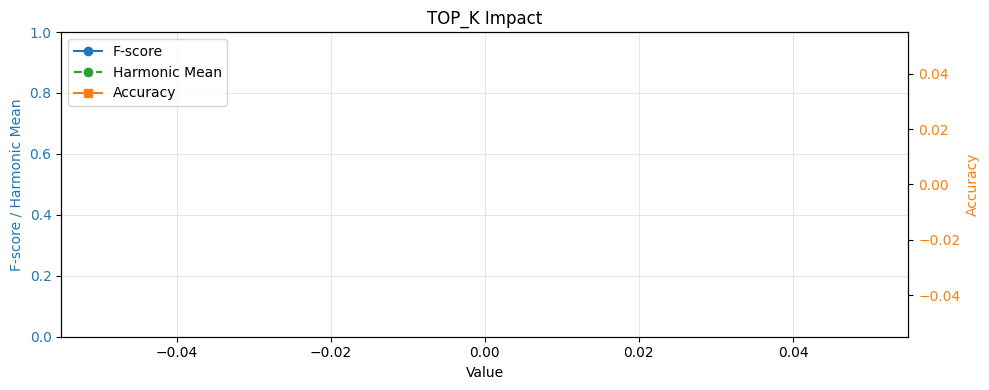

In [ ]:
def plot_hyperparameter_impacts(experiment_df):
    if experiment_df.empty:
        print("No experiment results available. Run the experiment cell first.")
        return

    params = experiment_df['parameter'].unique()
    for param in params:
        subset = experiment_df[experiment_df['parameter'] == param].copy()
        subset['sort_value'] = pd.to_numeric(subset['value'], errors='coerce')
        if subset['sort_value'].isna().all():
            subset = subset.sort_values('value')
        else:
            subset = subset.sort_values('sort_value')

        color_f = 'tab:blue'
        color_a = 'tab:orange'
        color_h = 'tab:green'

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(subset['value'], subset['F'], marker='o', color=color_f, label='F-score')
        ax.plot(subset['value'], subset['H'], marker='o', color=color_h, label='Harmonic Mean', linestyle='--')
        ax.set_title(f"{param} Impact")
        ax.set_xlabel('Value')
        ax.set_ylabel('F-score / Harmonic Mean', color=color_f)
        ax.set_ylim(0, 1)
        ax.tick_params(axis='y', labelcolor=color_f)

        ax2 = ax.twinx()
        ax2.plot(subset['value'], subset['A'], marker='s', color=color_a, label='Accuracy')
        ax2.set_ylabel('Accuracy', color=color_a)
        ax2.tick_params(axis='y', labelcolor=color_a)

        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines + lines2, labels + labels2, loc='upper left')

        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
print("\n=== Hyperparameter Impact Analysis ===")
print("experiment_records:", experiment_records)

print("experiment_results:\n", variant_experiments)

plot_hyperparameter_impacts(experiment_results)

In [ ]:
import datetime
def save_experiment_results(experiment_df, path):
    if experiment_df.empty:
        print("No experiment results to save.")
        return

    experiment_df.to_csv(path+'.csv', index=False)
    variant_experiments_path = path+'_variants.json'
    with open(variant_experiments_path, 'w', encoding='utf-8') as f:
        json.dump(variant_experiments, f, indent=2, ensure_ascii=True)
    print(f"Experiment results saved to {path}")
    
EXPERIMENT_CSV_PATH = str((PROJECT_ROOT / f"outputs/bert_experiment_results_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}").resolve())
save_experiment_results(experiment_results, EXPERIMENT_CSV_PATH)

Experiment results saved to C:\Code\COMP90042_2026\outputs\bert_experiment_results_2026-05-18_13-08-33



=== Detailed Plots for Each Hyperparameter (Grouped) ===

=== Diagnostic Summary for TOP_K ===


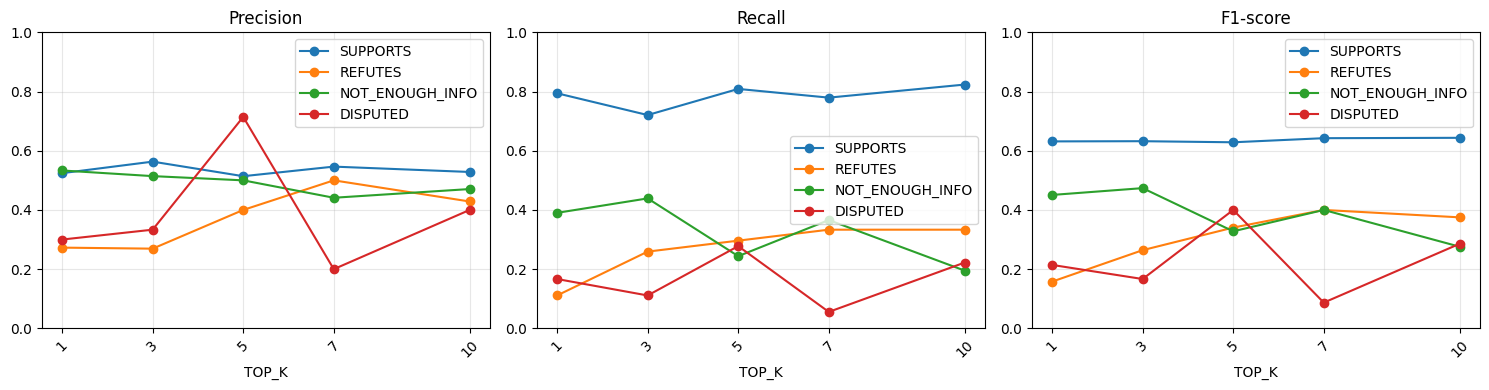

In [ ]:
              
print("\n=== Detailed Plots for Each Hyperparameter (Grouped) ===")
def diagnostic_plots_grouped(variant_experiments):
    import pandas as _pd

    for param, values in variant_experiments.items():
        print(f"\n=== Diagnostic Summary for {param} ===")

        # Collect and sort parameter values for consistent plotting
        value_keys = list(values.keys())
        try:
            # numeric sort if possible (ints/floats)
            sorted_keys = sorted(value_keys, key=lambda x: float(x))
        except Exception:
            # fallback to string ordering
            sorted_keys = list(value_keys)

        labels = LABELS
        metrics = ["precision", "recall", "f1-score"]

        # Build a wide dataframe: index=sorted_keys, columns=(label,metric)
        records = []
        for key in sorted_keys:
            row = {"_param_value": key}
            details = values.get(key, {}) or {}
            results = details.get("results", {}) if isinstance(details, dict) else {}
            diagnostics = results.get("Diagnostic", {}) if isinstance(results, dict) else {}

            for label in labels:
                lab = diagnostics.get(label, {})
                for m in metrics:
                    row[f"{label}|{m}"] = lab.get(m, float("nan"))

            records.append(row)

        if not records:
            print(f"No diagnostic results available for {param}")
            continue

        df = _pd.DataFrame.from_records(records).set_index("_param_value")

        # Prepare x positions and labels for plotting
        try:
            x_vals = [float(x) for x in df.index]
            x_labels = [str(x) for x in df.index]
        except Exception:
            x_vals = list(range(len(df.index)))
            x_labels = [str(x) for x in df.index]

        # Create one row of subplots (one per metric) and plot each label as a separate line
        fig, axes = plt.subplots(nrows=1, ncols=len(metrics), figsize=(5 * len(metrics), 4), squeeze=False)
        axes = axes.flatten()

        for ai, metric in enumerate(metrics):
            ax = axes[ai]
            for label in labels:
                col = f"{label}|{metric}"
                if col in df.columns:
                    try:
                        y = df[col].astype(float).values
                    except Exception:
                        y = df[col].values
                    ax.plot(x_vals, y, marker="o", label=label)

            ax.set_title(metric.capitalize())
            ax.set_ylim(0, 1)
            ax.set_xlabel(param)
            ax.set_xticks(x_vals)
            ax.set_xticklabels(x_labels, rotation=45)
            ax.grid(True, alpha=0.3)
            ax.legend()

        plt.tight_layout()
        plt.show()

diagnostic_plots_grouped(variant_experiments)

## Leaderboard Code

In [ ]:
# Used for participating in the ranking

if TRAIN_FINAL_ON_TRAIN_DEV:

    combined_claims = {**train_claims, **dev_claims}

    print("Training final classifier on train+dev gold evidence ...")

    final_model = fit_classifier(
        combined_claims,
        dev_claims_for_eval=None,
        checkpoint_path=FINAL_CKPT_PATH,
    )

    print("Updating supervised retrieval prior to train+dev ...")

    retriever.set_supervised_prior(combined_claims)

else:

    final_model = model

    print("Using train-only classifier and train-only retrieval prior for test prediction.")

print("Retrieving evidence for test claims ...")

test_retrieved = retriever.retrieve_many(test_claims, desc="Test retrieval")

print("Predicting test labels ...")

test_label_predictions = predict_claim_labels(final_model, test_claims, test_retrieved, tokenizer)

TEST_PRED_PATH = "test-claims-predictions.json"
test_predictions = write_prediction_file(
    TEST_PRED_PATH,
    test_claims,
    test_label_predictions,
    test_retrieved,
    include_claim_text=False,
)
validate_prediction_dict(test_predictions, test_claims, "Test predictions")

print("Test prediction file is ready for optional leaderboard submission.")

Using train-only classifier and train-only retrieval prior for test prediction.
Retrieving evidence for test claims ...


Test retrieval:  51%|█████     | 78/153 [06:33<06:18,  5.05s/it]


KeyboardInterrupt: 

## Object Oriented Programming codes here
You can use multiple code snippets. Just add more if needed